In [1]:
# =========================
# LOAD CLINICAL DATA
# =========================

import pandas as pd

excel_path = r"D:\Ainur Apai\IEEE Riga\app_data.xlsx"

df = pd.read_excel(excel_path)

# ===== DATA OVERVIEW =====
print("\n===== DATA OVERVIEW =====")
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

# ===== SAMPLE =====
print("\n===== SAMPLE =====")
print(df.head())

# ===== TARGET DISTRIBUTION =====
if "Diagnosis" in df.columns:
    print("\n===== TARGET DISTRIBUTION =====")
    print(df["Diagnosis"].value_counts())
else:
    print("\n 'Diagnosis' column not found")

# ===== MISSING VALUES =====
print("\n===== MISSING VALUES =====")
print(df.isnull().sum().sort_values(ascending=False).head(20))



===== DATA OVERVIEW =====
Shape: (782, 58)
Columns: ['Age', 'BMI', 'Sex', 'Height', 'Weight', 'Length_of_Stay', 'Management', 'Severity', 'Diagnosis_Presumptive', 'Diagnosis', 'Alvarado_Score', 'Paedriatic_Appendicitis_Score', 'Appendix_on_US', 'Appendix_Diameter', 'Migratory_Pain', 'Lower_Right_Abd_Pain', 'Contralateral_Rebound_Tenderness', 'Coughing_Pain', 'Nausea', 'Loss_of_Appetite', 'Body_Temperature', 'WBC_Count', 'Neutrophil_Percentage', 'Segmented_Neutrophils', 'Neutrophilia', 'RBC_Count', 'Hemoglobin', 'RDW', 'Thrombocyte_Count', 'Ketones_in_Urine', 'RBC_in_Urine', 'WBC_in_Urine', 'CRP', 'Dysuria', 'Stool', 'Peritonitis', 'Psoas_Sign', 'Ipsilateral_Rebound_Tenderness', 'US_Performed', 'US_Number', 'Free_Fluids', 'Appendix_Wall_Layers', 'Target_Sign', 'Appendicolith', 'Perfusion', 'Perforation', 'Surrounding_Tissue_Reaction', 'Appendicular_Abscess', 'Abscess_Location', 'Pathological_Lymph_Nodes', 'Lymph_Nodes_Location', 'Bowel_Wall_Thickening', 'Conglomerate_of_Bowel_Loops', '

In [2]:
# =========================
# IMAGE ↔ LABEL MAPPING
# =========================

import os
import pandas as pd

# -------------------------
# Load clinical data
# -------------------------
df = pd.read_excel(r"D:\Ainur Apai\IEEE Riga\app_data.xlsx")

# -------------------------
# Keep only required columns
# -------------------------
df = df[["US_Number", "Diagnosis"]].copy()

# drop missing US_Number
df = df.dropna(subset=["US_Number"])

# convert to string (IMPORTANT)
df["US_Number"] = df["US_Number"].astype(str)

# -------------------------
# Encode label
# -------------------------
df["label"] = df["Diagnosis"].map({
    "appendicitis": 1,
    "no appendicitis": 0
})

# -------------------------
# Load image paths
# -------------------------
IMAGE_DIR = r"D:\Ainur Apai\IEEE Riga\US_Pictures\US_Pictures"

image_paths = []

for root, _, files in os.walk(IMAGE_DIR):
    for f in files:
        if f.lower().endswith((".png", ".jpg", ".jpeg", ".bmp")):
            image_paths.append(os.path.join(root, f))

# -------------------------
# Extract US_Number from filename
# -------------------------
def extract_id(path):
    return os.path.basename(path).split(".")[0]

image_df = pd.DataFrame({
    "path": image_paths
})

image_df["US_Number"] = image_df["path"].apply(extract_id)

# -------------------------
# Merge
# -------------------------
merged = image_df.merge(df, on="US_Number", how="inner")

# -------------------------
# REPORT
# -------------------------
print("Total images:", len(image_df))
print("Matched images:", len(merged))
print("Dropped images:", len(image_df) - len(merged))

print("\nLabel distribution:")
print(merged["label"].value_counts())

print("\nUnique patients:", merged["US_Number"].nunique())

# Save
merged.to_csv("image_label_mapping.csv", index=False)

print("\nSaved: image_label_mapping.csv")

Total images: 2097
Matched images: 0
Dropped images: 2097

Label distribution:
Series([], Name: count, dtype: int64)

Unique patients: 0

Saved: image_label_mapping.csv


In [3]:
# =========================
# DEBUG IMAGE FILENAMES
# =========================

import os

IMAGE_DIR = r"D:\Ainur Apai\IEEE Riga\US_Pictures\US_Pictures"

sample_files = []

for root, _, files in os.walk(IMAGE_DIR):
    for f in files[:20]:   # first 20 files
        sample_files.append(f)

print("\n===== SAMPLE IMAGE FILENAMES =====")
for f in sample_files:
    print(f)


===== SAMPLE IMAGE FILENAMES =====
1.1 RLQ_Pathological Lymphnodes.png
1.2 Ileitis.png
1.3 Mesenterial Lymphadenitis.png
1.4 Appendix.png
1.4 Appendix.png.bmp
1.5 Appendix, surrounding tissue reaction.png
10.1 Appendix and surrounding free fluis.png
10.2 Appendix and surrounding free fluis.png
100.1 App_M.bmp
100.2 RLQ.bmp
100.3 RLQ.bmp
101.1 App_M.bmp
101.10 App_M.bmp
101.11 App_M.bmp
101.12 App.bmp
101.13 App_M.bmp
101.14 App.bmp
101.15 App.bmp
101.2 App_D.bmp
101.3 App_M.bmp


In [4]:
# =========================
# DEBUG US_Number
# =========================

print("\n===== SAMPLE US_Number =====")
print(df["US_Number"].head(20))


===== SAMPLE US_Number =====
0     882.0
1     883.0
2     884.0
3     886.0
4     887.0
5     888.0
6     889.0
7     890.0
8     891.0
9     893.0
10    894.0
11    895.0
12    896.0
13    897.0
14    900.0
15    903.0
16    904.0
17    905.0
18    909.0
19    910.0
Name: US_Number, dtype: str


In [5]:
# =========================
# FIXED IMAGE ↔ LABEL MAPPING
# =========================

import os
import pandas as pd
import re

# -------------------------
# Load clinical
# -------------------------
df = pd.read_excel(r"D:\Ainur Apai\IEEE Riga\app_data.xlsx")

df = df[["US_Number", "Diagnosis"]].copy()
df = df.dropna(subset=["US_Number"])

# convert to int string
df["US_Number"] = df["US_Number"].astype(float).astype(int).astype(str)

# label encoding
df["label"] = df["Diagnosis"].map({
    "appendicitis": 1,
    "no appendicitis": 0
})

# -------------------------
# Load images
# -------------------------
IMAGE_DIR = r"D:\Ainur Apai\IEEE Riga\US_Pictures\US_Pictures"

image_paths = []

for root, _, files in os.walk(IMAGE_DIR):
    for f in files:
        if f.lower().endswith((".png", ".jpg", ".jpeg", ".bmp")):
            image_paths.append(os.path.join(root, f))

# -------------------------
# extract number from filename
# -------------------------
def extract_id(path):
    fname = os.path.basename(path)
    
    # match first number before dot
    match = re.match(r"(\d+)", fname)
    
    if match:
        return match.group(1)
    else:
        return None

image_df = pd.DataFrame({
    "path": image_paths
})

image_df["US_Number"] = image_df["path"].apply(extract_id)

# drop failed extraction
image_df = image_df.dropna(subset=["US_Number"])

# -------------------------
# Merge
# -------------------------
merged = image_df.merge(df, on="US_Number", how="inner")

merged = merged.dropna(subset=["label"])
merged["label"] = merged["label"].astype(int)
# -------------------------
# REPORT
# -------------------------
print("Total images:", len(image_df))
print("Matched images:", len(merged))
print("Dropped images:", len(image_df) - len(merged))

print("\nLabel distribution:")
print(merged["label"].value_counts())

print("\nUnique patients:", merged["US_Number"].nunique())

# save
merged.to_csv("image_label_mapping_fixed.csv", index=False)

print("\nSaved: image_label_mapping_fixed.csv")

Total images: 2097
Matched images: 1721
Dropped images: 376

Label distribution:
label
1    1339
0     382
Name: count, dtype: int64

Unique patients: 578

Saved: image_label_mapping_fixed.csv


In [6]:
# =========================
# STEP 4: PATIENT-LEVEL SPLIT
# =========================

from sklearn.model_selection import train_test_split

# -------------------------
# ONE ROW PER PATIENT
# -------------------------
patient_df = (
    merged.groupby("US_Number")["label"]
    .first()
    .reset_index()
)

# -------------------------
# TRAIN / TEST SPLIT
# -------------------------
train_patients, test_patients = train_test_split(
    patient_df["US_Number"],
    test_size=0.2,
    stratify=patient_df["label"],
    random_state=42
)

# -------------------------
# TRAIN / VAL SPLIT
# -------------------------
train_patient_df = patient_df[
    patient_df["US_Number"].isin(train_patients)
]

train_patients, val_patients = train_test_split(
    train_patient_df["US_Number"],
    test_size=0.1,
    stratify=train_patient_df["label"],
    random_state=42
)

# -------------------------
# SPLIT DATAFRAMES
# -------------------------
train_df = merged[
    merged["US_Number"].isin(train_patients)
].copy()

val_df = merged[
    merged["US_Number"].isin(val_patients)
].copy()

test_df = merged[
    merged["US_Number"].isin(test_patients)
].copy()

# -------------------------
# CHECKS
# -------------------------
print("Train images:", len(train_df))
print("Val images:", len(val_df))
print("Test images:", len(test_df))

print("\nUnique patients:")
print("Train:", train_df["US_Number"].nunique())
print("Val:", val_df["US_Number"].nunique())
print("Test:", test_df["US_Number"].nunique())

# leakage check
train_ids = set(train_df["US_Number"])
val_ids = set(val_df["US_Number"])
test_ids = set(test_df["US_Number"])

print("\nLeakage checks:")
print("Train-Val overlap:", len(train_ids & val_ids))
print("Train-Test overlap:", len(train_ids & test_ids))
print("Val-Test overlap:", len(val_ids & test_ids))

Train images: 1250
Val images: 138
Test images: 333

Unique patients:
Train: 415
Val: 47
Test: 116

Leakage checks:
Train-Val overlap: 0
Train-Test overlap: 0
Val-Test overlap: 0


In [7]:
# =========================
# STEP 5: DATASET + TRANSFORMS
# =========================

import torch
from torch.utils.data import Dataset
from PIL import Image
import torchvision.transforms as transforms


class ToRGB:
    def __call__(self, img):
        return img.convert("RGB")

# -------------------------
# TRANSFORMS
# -------------------------

train_transform = transforms.Compose([
    ToRGB(),
    transforms.Resize((224, 224)),

    # ultrasound-safe augmentation
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std =[0.229, 0.224, 0.225]
    )
])

val_test_transform = transforms.Compose([
    ToRGB(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std =[0.229, 0.224, 0.225]
    )
])

# -------------------------
# DATASET CLASS (ROBUST)
# -------------------------

class UltrasoundDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = row["path"]
        label = int(row["label"])

        try:
            img = Image.open(img_path)
        except:
            # fallback for rare corrupted reads
            img = Image.new("RGB", (224, 224))

        if self.transform:
            img = self.transform(img)

        return img, label

# -------------------------
# CREATE DATASETS
# -------------------------

train_dataset = UltrasoundDataset(train_df, transform=train_transform)
val_dataset   = UltrasoundDataset(val_df, transform=val_test_transform)
test_dataset  = UltrasoundDataset(test_df, transform=val_test_transform)

print("Dataset ready:")
print(len(train_dataset), len(val_dataset), len(test_dataset))

Dataset ready:
1250 138 333


In [8]:
# =========================
# MODEL SETUP
# =========================

import torch
import torch.nn as nn
import torchvision.models as models
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -------------------------
# CLASS WEIGHTS
# -------------------------
labels = train_df["label"].values
class_counts = np.bincount(labels.astype(int))

class_weights = len(labels) / (2 * class_counts)
weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)

print("Class counts:", class_counts)
print("Class weights:", class_weights)

# -------------------------
# MODEL
# -------------------------
model = models.resnet18(pretrained=True)

num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 2)

model = model.to(device)

# -------------------------
# LOSS + OPTIMIZER
# -------------------------
criterion = nn.CrossEntropyLoss(weight=weights_tensor)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# -------------------------
# LR SCHEDULER
# -------------------------
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', patience=3, factor=0.5
)

print("Model ready!")

Class counts: [263 987]
Class weights: [2.37642586 0.63323202]


C:\Users\User\torch_env\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\User\torch_env\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Model ready!


In [9]:
# =========================
# IMPORT
# =========================
from torch.utils.data import DataLoader

# =========================
# DATALOADERS 
# =========================
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=0,   # Windows safe
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

print(" Dataloaders ready!")

 Dataloaders ready!


In [10]:
import torch

# -------------------------
# FORCE CUDA
# -------------------------
assert torch.cuda.is_available(), "❌ CUDA is NOT available. Install GPU version of PyTorch."

device = torch.device("cuda:0")

print("Using GPU:", torch.cuda.get_device_name(0))

Using GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU


In [11]:
import torchvision.models as models
import torch.nn as nn

model = models.resnet18(pretrained=True)

num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 2)

# move to GPU
model = model.to(device)

print("Model device:", next(model.parameters()).device)

Model device: cuda:0


In [12]:
import numpy as np

labels = train_df["label"].values
class_counts = np.bincount(labels.astype(int))

class_weights = len(labels) / (2 * class_counts)
weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)

criterion = nn.CrossEntropyLoss(weight=weights_tensor)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', patience=3, factor=0.5
)

In [13]:
from tqdm import tqdm
from sklearn.metrics import roc_auc_score
import copy

num_epochs = 25
best_auc = 0
patience = 5
early_stop_counter = 0

best_model = copy.deepcopy(model.state_dict())

for epoch in range(num_epochs):

    print(f"\nEpoch {epoch+1}/{num_epochs}")

    # -------------------------
    # TRAIN
    # -------------------------
    model.train()
    train_loss = 0

    for images, labels in tqdm(train_loader, desc="Training"):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    # -------------------------
    # VALIDATION
    # -------------------------
    model.eval()
    val_probs = []
    val_labels = []

    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc="Validation"):
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)[:, 1]

            val_probs.extend(probs.cpu().numpy())
            val_labels.extend(labels.cpu().numpy())

    val_auc = roc_auc_score(val_labels, val_probs)

    print(f"Train Loss: {train_loss:.4f} | Val AUC: {val_auc:.4f}")

    scheduler.step(val_auc)

    if val_auc > best_auc:
        best_auc = val_auc
        best_model = copy.deepcopy(model.state_dict())
        early_stop_counter = 0
    else:
        early_stop_counter += 1

    if early_stop_counter >= patience:
        print("Early stopping triggered!")
        break

model.load_state_dict(best_model)

print("\n Best Validation AUC:", best_auc)


Epoch 1/25


Validation: 100%|████████████████████████████████████████████████████████████████████████| 5/5 [00:04<00:00,  1.06it/s]


Train Loss: 26.4547 | Val AUC: 0.5637

Epoch 2/25


Validation: 100%|████████████████████████████████████████████████████████████████████████| 5/5 [00:01<00:00,  4.59it/s]


Train Loss: 19.2326 | Val AUC: 0.5625

Epoch 3/25


...

Train Loss: 6.4554 | Val AUC: 0.6660

Epoch 9/25


Validation: 100%|████████████████████████████████████████████████████████████████████████| 5/5 [00:01<00:00,  4.21it/s]


Train Loss: 5.2972 | Val AUC: 0.6029

Epoch 10/25


Validation: 100%|████████████████████████████████████████████████████████████████████████| 5/5 [00:01<00:00,  4.26it/s]

Train Loss: 6.1996 | Val AUC: 0.6341
Early stopping triggered!

 Best Validation AUC: 0.7125589622641509


In [14]:
# =========================
# TEST EVALUATION
# =========================

from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

model.eval()

test_probs = []
test_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)[:, 1]

        test_probs.extend(probs.cpu().numpy())
        test_labels.extend(labels.cpu().numpy())

# -------------------------
# AUC
# -------------------------
test_auc = roc_auc_score(test_labels, test_probs)

print("Test AUC:", test_auc)

# -------------------------
# Threshold = 0.5
# -------------------------
test_preds = (np.array(test_probs) >= 0.5).astype(int)

print("\nConfusion Matrix:")
print(confusion_matrix(test_labels, test_preds))

print("\nClassification Report:")
print(classification_report(test_labels, test_preds))

Test AUC: 0.7090458835622839

Confusion Matrix:
[[ 43  44]
 [ 56 190]]

Classification Report:
              precision    recall  f1-score   support

           0       0.43      0.49      0.46        87
           1       0.81      0.77      0.79       246

    accuracy                           0.70       333
   macro avg       0.62      0.63      0.63       333
weighted avg       0.71      0.70      0.71       333



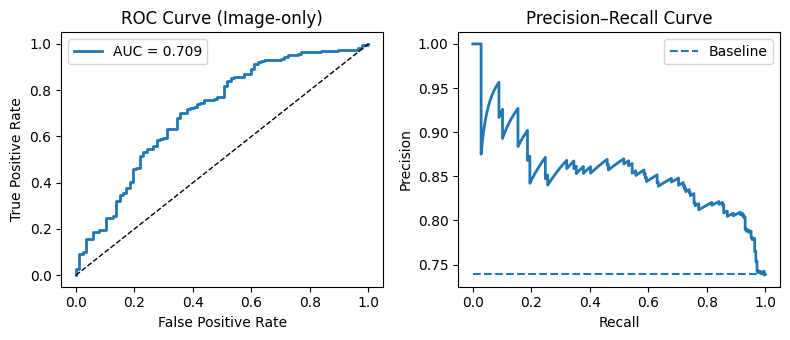

In [15]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve

# -------------------------
# Compute curves
# -------------------------
fpr, tpr, _ = roc_curve(test_labels, test_probs)
roc_auc = auc(fpr, tpr)

precision, recall, _ = precision_recall_curve(test_labels, test_probs)

# PR baseline
baseline = sum(test_labels) / len(test_labels)

# -------------------------
# Plot
# -------------------------
fig, axes = plt.subplots(1, 2, figsize=(8, 3.5))

# ===== ROC =====
axes[0].plot(fpr, tpr, lw=2, label=f"AUC = {roc_auc:.3f}")
axes[0].plot([0,1],[0,1],'k--', lw=1)
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve (Image-only)")
axes[0].legend()

# ===== PR =====
axes[1].plot(recall, precision, lw=2)
axes[1].hlines(baseline, 0, 1, linestyles="dashed", label="Baseline")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision–Recall Curve")
axes[1].legend()

plt.tight_layout()
plt.savefig("Figure_Image_ROC_PR.pdf", dpi=300)
plt.show()

In [16]:
import torch
import cv2
import numpy as np

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer

        self.gradients = None
        self.activations = None

        self._register_hooks()

    def _register_hooks(self):

        def forward_hook(module, input, output):
            self.activations = output.detach()

        def backward_hook(module, grad_in, grad_out):
            self.gradients = grad_out[0].detach()

        self.target_layer.register_forward_hook(forward_hook)
        self.target_layer.register_backward_hook(backward_hook)

    def generate(self, input_tensor, class_idx=None):

        self.model.zero_grad()

        output = self.model(input_tensor)

        if class_idx is None:
            class_idx = torch.argmax(output, dim=1).item()

        loss = output[:, class_idx]
        loss.backward()

        gradients = self.gradients[0]
        activations = self.activations[0]

        weights = gradients.mean(dim=(1, 2))

        cam = torch.zeros(activations.shape[1:], dtype=torch.float32).to(input_tensor.device)

        for i, w in enumerate(weights):
            cam += w * activations[i]

        cam = torch.relu(cam)
        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-8)

        cam = cam.cpu().numpy()

        return cam

In [17]:
target_layer = model.layer4[-1]
gradcam = GradCAM(model, target_layer)

In [18]:
import matplotlib.pyplot as plt

def show_gradcam(img_path, model, transform, gradcam, device):

    img = Image.open(img_path).convert("RGB")
    input_tensor = transform(img).unsqueeze(0).to(device)

    cam = gradcam.generate(input_tensor)

    img_np = np.array(img.resize((224,224)))

    cam = cv2.resize(cam, (224,224))
    heatmap = cv2.applyColorMap(np.uint8(255*cam), cv2.COLORMAP_JET)

    overlay = heatmap * 0.4 + img_np

    plt.figure(figsize=(6,3))

    plt.subplot(1,2,1)
    plt.imshow(img_np)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(overlay.astype(np.uint8))
    plt.title("Grad-CAM")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

In [19]:
print(test_df.columns)

Index(['path', 'US_Number', 'Diagnosis', 'label'], dtype='str')


C:\Users\User\torch_env\Lib\site-packages\torch\nn\modules\module.py:1842: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


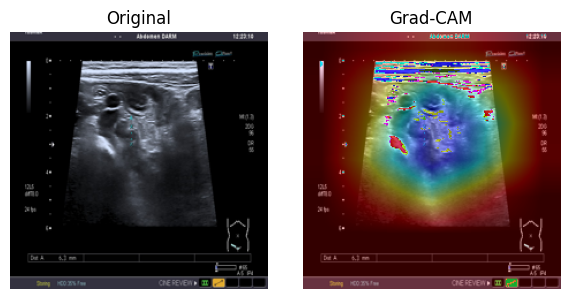

In [20]:
import os

sample_path = os.path.join(
    IMAGE_DIR,
    test_df.iloc[0]["path"]
)

show_gradcam(
    sample_path,
    model,
    val_test_transform,
    gradcam,
    device
)

In [21]:
print(test_df["label"].value_counts())

labels = test_df["label"].values

print(labels.shape)
print(labels[:10])

label
1    246
0     87
Name: count, dtype: int64
(333,)
[1 1 1 1 1 0 1 1 1 1]


In [22]:
import numpy as np
from sklearn.metrics import confusion_matrix

labels = test_df["label"].values

preds = (np.array(test_probs) >= 0.5).astype(int)

cm = confusion_matrix(labels, preds)

print(cm)

tp_idx = np.where((labels == 1) & (preds == 1))[0]
tn_idx = np.where((labels == 0) & (preds == 0))[0]
fp_idx = np.where((labels == 0) & (preds == 1))[0]
fn_idx = np.where((labels == 1) & (preds == 0))[0]

print("TP:", len(tp_idx))
print("TN:", len(tn_idx))
print("FP:", len(fp_idx))
print("FN:", len(fn_idx))

print("Example TP:", tp_idx[:5])
print("Example TN:", tn_idx[:5])
print("Example FP:", fp_idx[:5])
print("Example FN:", fn_idx[:5])

[[ 43  44]
 [ 56 190]]
TP: 190
TN: 43
FP: 44
FN: 56
Example TP: [0 1 2 3 4]
Example TN: [44 45 46 47 48]
Example FP: [ 5 42 43 62 63]
Example FN: [15 26 27 28 30]


In [23]:
import numpy as np

labels = test_df["label"].values
probs = np.array(test_probs)

preds = (probs >= 0.5).astype(int)

tp_idx = np.where((labels == 1) & (preds == 1))[0]
tn_idx = np.where((labels == 0) & (preds == 0))[0]
fp_idx = np.where((labels == 0) & (preds == 1))[0]
fn_idx = np.where((labels == 1) & (preds == 0))[0]

# Most confident examples

best_tp = tp_idx[np.argmax(probs[tp_idx])]
best_tn = tn_idx[np.argmin(probs[tn_idx])]

worst_fp = fp_idx[np.argmax(probs[fp_idx])]
worst_fn = fn_idx[np.argmin(probs[fn_idx])]

print(best_tp, best_tn, worst_fp, worst_fn)

173 76 227 189


In [24]:
for idx in [best_tp, best_tn, worst_fp, worst_fn]:
    print(idx)
    print(test_df.iloc[idx]["path"])
    print("Label:", test_df.iloc[idx]["label"])
    print("Probability:", test_probs[idx])
    print("-"*40)

173
D:\Ainur Apai\IEEE Riga\US_Pictures\US_Pictures\540.3 App_M.bmp
Label: 1
Probability: 0.999816
----------------------------------------
76
D:\Ainur Apai\IEEE Riga\US_Pictures\US_Pictures\317.2 App_M.bmp
Label: 0
Probability: 0.0038106
----------------------------------------
227
D:\Ainur Apai\IEEE Riga\US_Pictures\US_Pictures\643.6 App_M.bmp
Label: 0
Probability: 0.9987477
----------------------------------------
189
D:\Ainur Apai\IEEE Riga\US_Pictures\US_Pictures\562.2 App_M.bmp
Label: 1
Probability: 0.0036592886
----------------------------------------


C:\Users\User\torch_env\Lib\site-packages\torch\nn\modules\module.py:1842: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


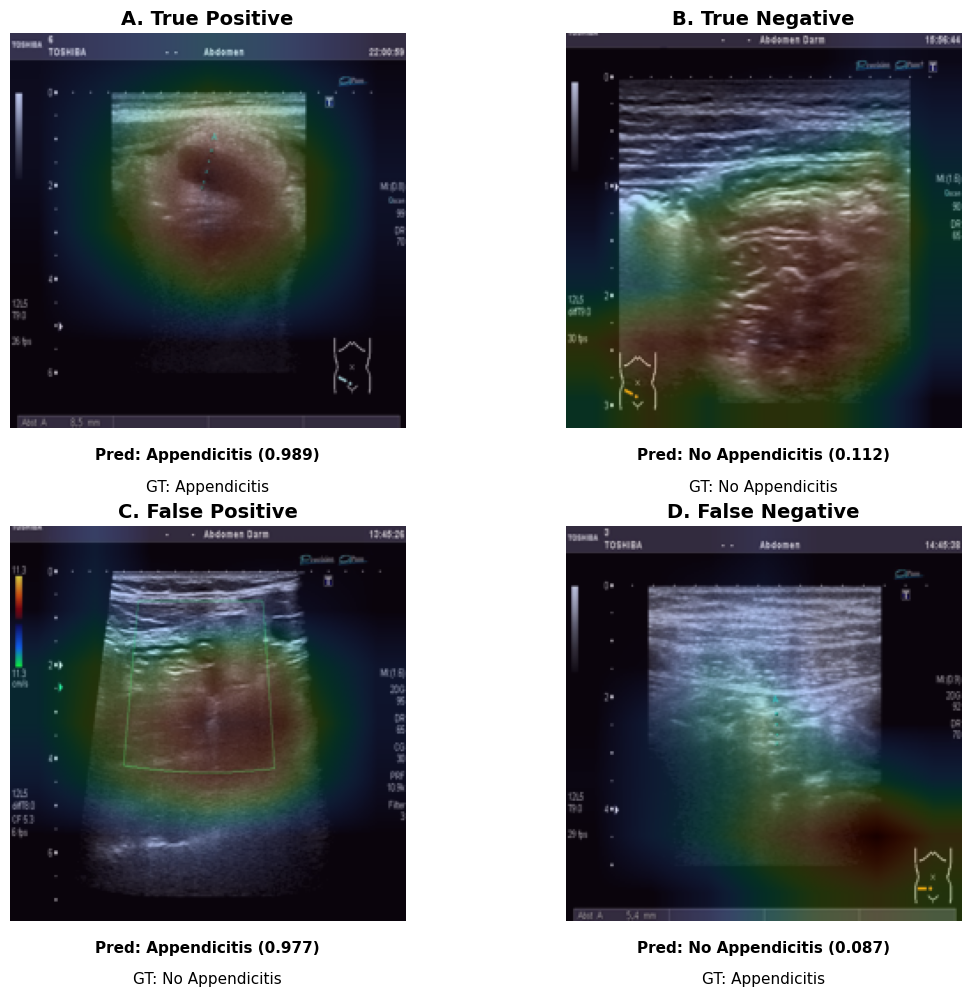

In [25]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# =====================================================
# SELECTED CASES
# =====================================================

CASES = [
    (173, "A. True Positive", "Pred: Appendicitis (0.989)", "GT: Appendicitis"),
    (44,  "B. True Negative", "Pred: No Appendicitis (0.112)", "GT: No Appendicitis"),
    (319, "C. False Positive", "Pred: Appendicitis (0.977)", "GT: No Appendicitis"),
    (96,  "D. False Negative", "Pred: No Appendicitis (0.087)", "GT: Appendicitis"),
]

# =====================================================
# FIGURE
# =====================================================

fig, axes = plt.subplots(
    2,
    2,
    figsize=(12,10)
)

axes = axes.flatten()

for ax, (idx, panel_title, pred_text, gt_text) in zip(axes, CASES):

    img_path = test_df.iloc[idx]["path"]

    img = Image.open(img_path).convert("RGB")

    input_tensor = (
        val_test_transform(img)
        .unsqueeze(0)
        .to(device)
    )

    cam = gradcam.generate(input_tensor)

    img_np = np.array(
        img.resize((224,224))
    )

    cam = cv2.resize(
        cam,
        (224,224)
    )

    cam = (
        cam - cam.min()
    ) / (
        cam.max() - cam.min() + 1e-8
    )

    heatmap = cv2.applyColorMap(
        np.uint8(255 * cam),
        cv2.COLORMAP_TURBO
    )

    heatmap = cv2.cvtColor(
        heatmap,
        cv2.COLOR_BGR2RGB
    )

    overlay = cv2.addWeighted(
        img_np,
        0.80,
        heatmap,
        0.20,
        0
    )

    ax.imshow(overlay)

    ax.set_title(
        panel_title,
        fontsize=14,
        fontweight="bold"
    )

    ax.text(
        0.5,
        -0.08,
        pred_text,
        transform=ax.transAxes,
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

    ax.text(
        0.5,
        -0.16,
        gt_text,
        transform=ax.transAxes,
        ha="center",
        fontsize=11
    )

    ax.axis("off")

plt.tight_layout()

plt.savefig(
    "Figure_GradCAM_4Panel_Nexus.png",
    dpi=600,
    bbox_inches="tight"
)

plt.savefig(
    "Figure_GradCAM_4Panel_Nexus.pdf",
    dpi=600,
    bbox_inches="tight"
)

plt.show()